# The Chain Rule — Heart of Deep Learning

Deep Learning ඉගෙන ගන්න කලින් **Chain Rule** එක හරියට තේරුම් ගන්න ඕනේ. Backpropagation, gradient computation, weight updates — හැම එකම Chain Rule එක උඩ තමයි පදනම් වෙන්නේ.

මේ notebook එකෙන් අපි:

1. Basic calculus Chain Rule එක explain කරනවා
2. Multi-variable Chain Rule එක cover කරනවා
3. Computational Graph එකක් draw කරලා visualize කරනවා
4. Neural Network එකක එකින් එක layer එකට chain rule apply කරන හැටි බලනවා
5. General Deep Learning implementation එකක් from scratch build කරනවා

---

## Table of Contents

1. [What is the Chain Rule?](#1)
2. [Single Variable Chain Rule](#2)
3. [Multi-Variable Chain Rule](#3)
4. [Computational Graphs](#4)
5. [Chain Rule in Neural Networks](#5)
6. [General Deep Learning Implementation](#6)
7. [Training on Real-ish Data](#7)
8. [Gradient Checking (Numerical vs Analytical)](#8)
9. [Summary](#9)

---

<a id="1"></a>
## 1. What is the Chain Rule?

Chain Rule එක කියන්නේ **composite functions** (function ඇතුළේ function) වල **derivative** ගන්න use කරන rule එක.

### Real-World Analogy:

හිතන්න ඔයා car එකක accelerator pedal එක press කරනවා:

```
Pedal Push → Engine RPM → Wheel Speed → Car Speed
```

"Pedal push එක car speed එකට කොහොමද affect කරන්නේ?" කියලා හොයන්න නම්, හැම intermediate step එකේම **rate of change** එක multiply කරන්න ඕනේ:

$$\frac{d(\text{car speed})}{d(\text{pedal})} = \frac{d(\text{car speed})}{d(\text{wheel speed})} \times \frac{d(\text{wheel speed})}{d(\text{RPM})} \times \frac{d(\text{RPM})}{d(\text{pedal})}$$

Neural Network එකේත් exactly මේක තමයි වෙන්නේ — **Loss එක weight එකකට කොහොමද depend වෙන්නේ** කියලා හොයනකොට, ඒ අතරේ තියෙන හැම layer එකේම rate of change multiply කරනවා.

---

<a id="2"></a>
## 2. Single Variable Chain Rule

### Definition:

If $y = f(u)$ and $u = g(x)$, then:

$$\boxed{\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}}$$

Intermediate variable $u$ cancel out වෙනවා (fraction multiplication වගේ!).

### Why it Works (Intuition):

$x$ ටිකක් change වුනොත් → $u$ ටිකක් change වෙනවා → $y$ ටිකක් change වෙනවා

$$\Delta y \approx \frac{dy}{du} \cdot \Delta u \approx \frac{dy}{du} \cdot \frac{du}{dx} \cdot \Delta x$$

In [160]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Example 1: Simple Chain Rule
# ============================================================
#
# y = (2x + 3)^4
#
# Let u = 2x + 3 → du/dx = 2
# y = u^4 → dy/du = 4u^3
#
# dy/dx = dy/du × du/dx = 4u^3 × 2 = 8(2x + 3)^3

def f(x):
 """y = (2x + 3)^4"""
 return (2*x + 3)**4

def f_derivative_analytical(x):
 """dy/dx = 8(2x + 3)^3 — using chain rule"""
 return 8 * (2*x + 3)**3

def f_derivative_numerical(x, h=1e-7):
 """Numerical derivative: lim (f(x+h) - f(x-h)) / 2h"""
 return (f(x + h) - f(x - h)) / (2 * h)


# --- Verify: analytical == numerical ---
test_points = [-2, -1, 0, 1, 2, 3]

print("Example 1: y = (2x + 3)⁴")
print("Chain Rule: dy/dx = 8(2x + 3)³")
print()
print(f"{'x':>5} {'Analytical':>14} {'Numerical':>14} {'Match?':>8}")
print("─" * 48)

for x in test_points:
 a = f_derivative_analytical(x)
 n = f_derivative_numerical(x)
 match = "" if abs(a - n) < 1e-4 else ""
 print(f"{x:>5} {a:>14.4f} {n:>14.4f} {match:>8}")

print("\n Analytical (chain rule) සහ Numerical derivatives match වෙනවා!")

Example 1: y = (2x + 3)⁴
Chain Rule: dy/dx = 8(2x + 3)³

    x     Analytical      Numerical   Match?
────────────────────────────────────────────────
   -2        -8.0000        -8.0000         
   -1         8.0000         8.0000         
    0       216.0000       216.0000         
    1      1000.0000      1000.0000         
    2      2744.0000      2744.0000         
    3      5832.0000      5832.0000         

 Analytical (chain rule) සහ Numerical derivatives match වෙනවා!


In [161]:
# ============================================================
# Example 2: Deeper Chain — 3 levels
# ============================================================
#
# y = sin(e^(x^2))
#
# Layer 1: a = x² → da/dx = 2x
# Layer 2: b = e^a → db/da = e^a
# Layer 3: y = sin(b) → dy/db = cos(b)
#
# dy/dx = dy/db × db/da × da/dx
# = cos(e^(x²)) × e^(x²) × 2x

print("\n" + "=" * 60)
print("Example 2: y = sin(e^(x²)) — THREE-LEVEL CHAIN")
print("=" * 60)

def g(x):
 return np.sin(np.exp(x**2))

def g_chain_rule(x):
 """dy/dx = cos(e^(x²)) × e^(x²) × 2x"""
 a = x**2
 b = np.exp(a)
 
 da_dx = 2 * x # Layer 1 derivative
 db_da = np.exp(a) # Layer 2 derivative
 dy_db = np.cos(b) # Layer 3 derivative
 
 # Chain them together!
 dy_dx = dy_db * db_da * da_dx
 return dy_dx

def g_numerical(x, h=1e-7):
 return (g(x + h) - g(x - h)) / (2 * h)


print("\n Decomposition:")
print(" ┌───────────┐ ┌───────────┐ ┌────────────┐")
print(" │ a = x² │───▶│ b = eᵃ │───▶│ y = sin(b) │")
print(" │ da/dx = 2x│ │ db/da = eᵃ│ │ dy/db=cos(b)│")
print(" └───────────┘ └───────────┘ └────────────┘")
print()
print(" dy/dx = cos(eˣ²) × eˣ² × 2x")

print(f"\n{'x':>6} {'Layer1 da/dx':>14} {'Layer2 db/da':>14} {'Layer3 dy/db':>14} │ {'Chain Rule':>12} {'Numerical':>12} {'OK?'}")
print("─" * 105)

for x in [0.1, 0.3, 0.5, 0.7, 0.9]:
 a = x**2
 b = np.exp(a)
 
 da_dx = 2 * x
 db_da = np.exp(a)
 dy_db = np.cos(b)
 
 chain = g_chain_rule(x)
 numer = g_numerical(x)
 ok = "" if abs(chain - numer) < 1e-3 else ""
 
 print(f"{x:>6.1f} {da_dx:>14.6f} {db_da:>14.6f} {dy_db:>14.6f} │ {chain:>12.6f} {numer:>12.6f} {ok}")

print("\n Each layer's local derivative multiply කරලා full derivative ලැබෙනවා.")
print(" මේකයි Neural Network එකේ layer-by-layer gradient flow එකේ basis එක!")


Example 2: y = sin(e^(x²)) — THREE-LEVEL CHAIN

 Decomposition:
 ┌───────────┐ ┌───────────┐ ┌────────────┐
 │ a = x² │───▶│ b = eᵃ │───▶│ y = sin(b) │
 │ da/dx = 2x│ │ db/da = eᵃ│ │ dy/db=cos(b)│
 └───────────┘ └───────────┘ └────────────┘

 dy/dx = cos(eˣ²) × eˣ² × 2x

     x   Layer1 da/dx   Layer2 db/da   Layer3 dy/db │   Chain Rule    Numerical OK?
─────────────────────────────────────────────────────────────────────────────────────────────────────────
   0.1       0.200000       1.010050       0.531818 │     0.107433     0.107433 
   0.3       0.600000       1.094174       0.458780 │     0.301191     0.301191 
   0.5       1.000000       1.284025       0.282856 │     0.363195     0.363195 
   0.7       1.400000       1.632316      -0.061481 │    -0.140499    -0.140499 
   0.9       1.800000       2.247908      -0.626545 │    -2.535146    -2.535146 

 Each layer's local derivative multiply කරලා full derivative ලැබෙනවා.
 මේකයි Neural Network එකේ layer-by-layer gradient flow එකේ ba

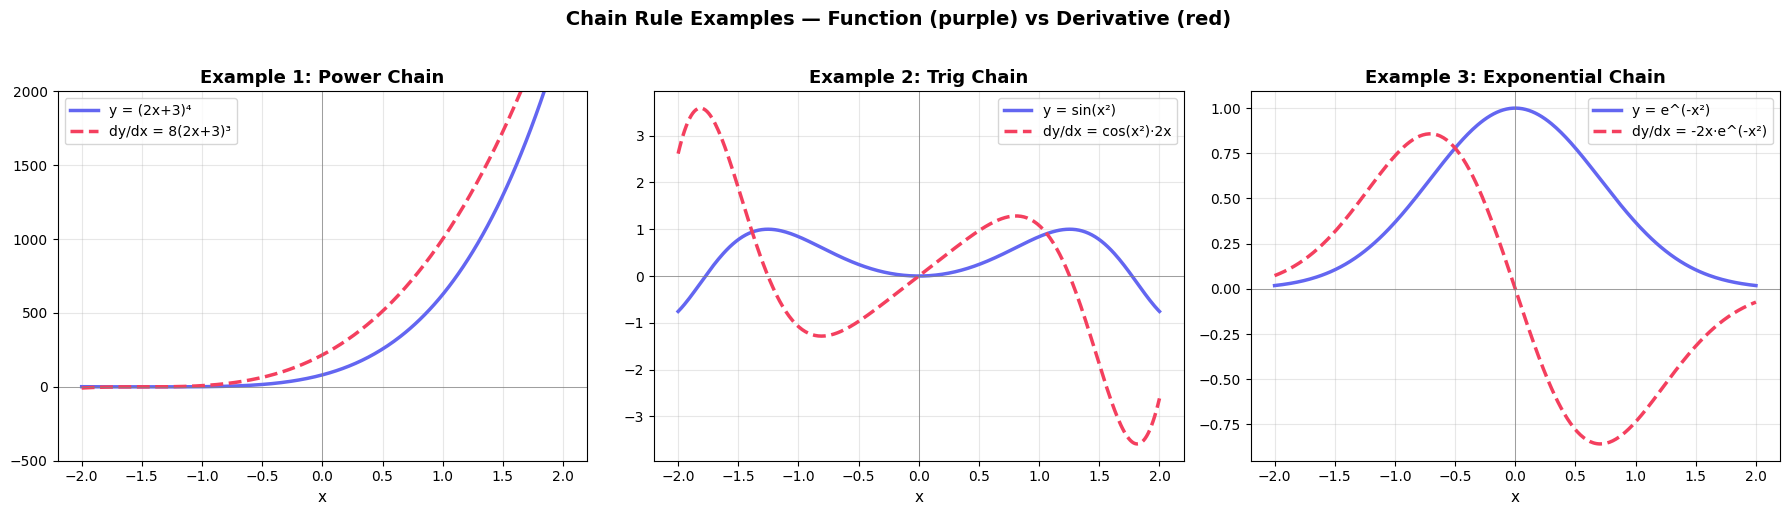

In [162]:
# ============================================================
# Visualize: Function and its Chain-Rule Derivative
# ============================================================

x_vals = np.linspace(-2, 2, 300)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Example 1: y = (2x+3)^4 ---
y1 = (2*x_vals + 3)**4
dy1 = 8 * (2*x_vals + 3)**3

axes[0].plot(x_vals, y1, color='#6366f1', linewidth=2.5, label='y = (2x+3)⁴')
axes[0].plot(x_vals, dy1, color='#f43f5e', linewidth=2.5, linestyle='--', label="dy/dx = 8(2x+3)³")
axes[0].set_title('Example 1: Power Chain', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-500, 2000)

# --- Example 2: y = sin(x²) ---
y2 = np.sin(x_vals**2)
dy2 = np.cos(x_vals**2) * 2 * x_vals # chain rule

axes[1].plot(x_vals, y2, color='#6366f1', linewidth=2.5, label='y = sin(x²)')
axes[1].plot(x_vals, dy2, color='#f43f5e', linewidth=2.5, linestyle='--', label="dy/dx = cos(x²)·2x")
axes[1].set_title('Example 2: Trig Chain', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# --- Example 3: y = e^(-x²) (Gaussian-like) ---
y3 = np.exp(-x_vals**2)
dy3 = np.exp(-x_vals**2) * (-2 * x_vals) # chain rule

axes[2].plot(x_vals, y3, color='#6366f1', linewidth=2.5, label='y = e^(-x²)')
axes[2].plot(x_vals, dy3, color='#f43f5e', linewidth=2.5, linestyle='--', label="dy/dx = -2x·e^(-x²)")
axes[2].set_title('Example 3: Exponential Chain', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

for ax in axes:
 ax.axhline(y=0, color='gray', linewidth=0.5)
 ax.axvline(x=0, color='gray', linewidth=0.5)
 ax.set_xlabel('x', fontsize=11)

plt.suptitle(' Chain Rule Examples — Function (purple) vs Derivative (red)', 
 fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

<a id="3"></a>
## 3. Multi-Variable Chain Rule

Neural Networks වලදී variable එකක් **multiple paths** වලින් output එකට affect කරනවා. එතකොට **Multivariable Chain Rule** use කරන්න ඕනේ.

### Case 1: Single Path

If $L = f(y)$, $y = g(z)$, $z = h(w)$:

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial y} \cdot \frac{\partial y}{\partial z} \cdot \frac{\partial z}{\partial w}$$

### Case 2: Multiple Paths (SUM over paths)

If $L = f(a, b)$ and both $a = g(x)$ and $b = h(x)$:

$$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial x} + \frac{\partial L}{\partial b} \cdot \frac{\partial b}{\partial x}$$

```
 ┌── a ──┐
 x ──┤ ├── L
 └── b ──┘
 
 x influences L through BOTH a and b
 → sum the gradients from each path
```

> **Key Rule:** Variable එකක gradient ගන්නකොට, ඒ variable එක output එකට reach වෙන **හැම path එකකම** gradient **SUM** කරන්න ඕනේ.

In [163]:
# ============================================================
# Multi-Variable Chain Rule Example
# ============================================================
#
# L = (a - target)² where a = x·w₁ + x·w₂
#
# x influences L through BOTH w₁ path and w₂ path
#
# ∂L/∂x = ∂L/∂a × (∂a/∂(x·w₁) × w₁ + ∂a/∂(x·w₂) × w₂)
# = 2(a - target) × (w₁ + w₂)

print("=" * 60)
print(" Multi-Variable Chain Rule Example")
print("=" * 60)
print()
print(" Computation:")
print(" ┌─────────────────────────────────────────────┐")
print(" │ path₁ = x × w₁ │")
print(" │ path₂ = x × w₂ │")
print(" │ a = path₁ + path₂ = x×w₁ + x×w₂ │")
print(" │ L = (a - target)² │")
print(" └─────────────────────────────────────────────┘")

# Values
x = 3.0
w1 = 2.0
w2 = 5.0
target = 10.0

# Forward
path1 = x * w1
path2 = x * w2
a = path1 + path2
L = (a - target) ** 2

print(f"\n Forward Pass:")
print(f" x = {x}, w₁ = {w1}, w₂ = {w2}, target = {target}")
print(f" path₁ = {x} × {w1} = {path1}")
print(f" path₂ = {x} × {w2} = {path2}")
print(f" a = {path1} + {path2} = {a}")
print(f" L = ({a} - {target})² = {L}")

# Backward — chain rule
dL_da = 2 * (a - target) # ∂L/∂a
da_dpath1 = 1.0 # ∂a/∂path₁ (addition)
da_dpath2 = 1.0 # ∂a/∂path₂ (addition)
dpath1_dx = w1 # ∂path₁/∂x
dpath2_dx = w2 # ∂path₂/∂x
dpath1_dw1 = x # ∂path₁/∂w₁
dpath2_dw2 = x # ∂path₂/∂w₂

# Multi-path: sum over paths
dL_dx = dL_da * (da_dpath1 * dpath1_dx + da_dpath2 * dpath2_dx)
dL_dw1 = dL_da * da_dpath1 * dpath1_dw1
dL_dw2 = dL_da * da_dpath2 * dpath2_dw2

print(f"\n Backward Pass (Chain Rule):")
print(f" ∂L/∂a = 2(a - target) = 2({a} - {target}) = {dL_da}")
print(f"")
print(f" ∂L/∂x = ∂L/∂a × (w₁ + w₂) ← SUM over both paths")
print(f" = {dL_da} × ({w1} + {w2}) = {dL_dx}")
print(f"")
print(f" ∂L/∂w₁ = ∂L/∂a × x = {dL_da} × {x} = {dL_dw1}")
print(f" ∂L/∂w₂ = ∂L/∂a × x = {dL_da} × {x} = {dL_dw2}")

# Numerical verification
h = 1e-7
dL_dx_num = ((((x+h)*w1 + (x+h)*w2) - target)**2 - (((x-h)*w1 + (x-h)*w2) - target)**2) / (2*h)
dL_dw1_num = (((x*(w1+h) + x*w2) - target)**2 - ((x*(w1-h) + x*w2) - target)**2) / (2*h)

print(f"\n Verification (numerical):")
print(f" ∂L/∂x analytical={dL_dx:.4f}, numerical={dL_dx_num:.4f} {'' if abs(dL_dx - dL_dx_num) < 1e-3 else ''}")
print(f" ∂L/∂w₁ analytical={dL_dw1:.4f}, numerical={dL_dw1_num:.4f} {'' if abs(dL_dw1 - dL_dw1_num) < 1e-3 else ''}")

 Multi-Variable Chain Rule Example

 Computation:
 ┌─────────────────────────────────────────────┐
 │ path₁ = x × w₁ │
 │ path₂ = x × w₂ │
 │ a = path₁ + path₂ = x×w₁ + x×w₂ │
 │ L = (a - target)² │
 └─────────────────────────────────────────────┘

 Forward Pass:
 x = 3.0, w₁ = 2.0, w₂ = 5.0, target = 10.0
 path₁ = 3.0 × 2.0 = 6.0
 path₂ = 3.0 × 5.0 = 15.0
 a = 6.0 + 15.0 = 21.0
 L = (21.0 - 10.0)² = 121.0

 Backward Pass (Chain Rule):
 ∂L/∂a = 2(a - target) = 2(21.0 - 10.0) = 22.0

 ∂L/∂x = ∂L/∂a × (w₁ + w₂) ← SUM over both paths
 = 22.0 × (2.0 + 5.0) = 154.0

 ∂L/∂w₁ = ∂L/∂a × x = 22.0 × 3.0 = 66.0
 ∂L/∂w₂ = ∂L/∂a × x = 22.0 × 3.0 = 66.0

 Verification (numerical):
 ∂L/∂x analytical=154.0000, numerical=154.0000 
 ∂L/∂w₁ analytical=66.0000, numerical=66.0000 


---

<a id="4"></a>
## 4. Computational Graphs

Deep Learning frameworks (PyTorch, TensorFlow) internally **computational graph** එකක් build කරනවා. Forward pass එකේදී graph එක build වෙනවා, backward pass එකේදී graph එක reverse order එකේ traverse කරලා gradients compute කරනවා.

### Rules:

| Operation | Forward | Local Gradient (backward) |
|-----------|---------|---------------------------|
| Addition: $c = a + b$ | $c = a + b$ | $\frac{\partial c}{\partial a} = 1, \quad \frac{\partial c}{\partial b} = 1$ |
| Multiplication: $c = a \times b$ | $c = a \times b$ | $\frac{\partial c}{\partial a} = b, \quad \frac{\partial c}{\partial b} = a$ |
| Power: $c = a^n$ | $c = a^n$ | $\frac{\partial c}{\partial a} = n \cdot a^{n-1}$ |
| Sigmoid: $c = \sigma(a)$ | $c = \frac{1}{1+e^{-a}}$ | $\frac{\partial c}{\partial a} = c(1-c)$ |
| ReLU: $c = \max(0, a)$ | $c = \max(0, a)$ | $\frac{\partial c}{\partial a} = \begin{cases} 1 & a > 0 \\ 0 & a \leq 0 \end{cases}$ |

### Backward Pass Rule:

Each node gets an **upstream gradient** and multiplies it by the **local gradient**, then passes it backward.

$$\text{downstream gradient} = \text{upstream gradient} \times \text{local gradient}$$

In [164]:
# ============================================================
# Computational Graph — Manual Step-by-Step
# ============================================================
#
# Compute: L = (σ(w·x + b) - y)²
#
# Graph:
# x,w → [mul] → p → [add] → z → [sigmoid] → a → [sub] → d → [square] → L
# b ──┘ y ──┘

print("=" * 70)
print(" Computational Graph: L = (σ(w·x + b) - y)²")
print("=" * 70)
print()
print(" Forward Graph:")
print(" x,w ──▶ [MUL] ──▶ p ──▶ [ADD] ──▶ z ──▶ [σ] ──▶ a ──▶ [SUB] ──▶ d ──▶ [SQ] ──▶ L")
print(" b ──┘ y ──┘")

# --- Values ---
x = 2.0
w = -3.0
b = 1.0
y = 1.0

# ======= FORWARD PASS =======
p = w * x # multiply
z = p + b # add
a = 1 / (1 + np.exp(-z)) # sigmoid
d = a - y # subtract
L = d ** 2 # square

print(f"\n ── FORWARD PASS ──")
print(f" Step 1: p = w × x = {w} × {x} = {p}")
print(f" Step 2: z = p + b = {p} + {b} = {z}")
print(f" Step 3: a = σ(z) = σ({z}) = {a:.6f}")
print(f" Step 4: d = a - y = {a:.6f} - {y} = {d:.6f}")
print(f" Step 5: L = d² = ({d:.6f})² = {L:.6f}")

# ======= BACKWARD PASS (reverse order!) =======
print(f"\n ── BACKWARD PASS (Chain Rule, node by node) ──")
print(f" Starting with ∂L/∂L = 1.0")

dL_dL = 1.0

# Node: L = d² → local grad = 2d
dL_dd = dL_dL * (2 * d)
print(f"\n Node [SQUARE]: L = d²")
print(f" local grad: ∂L/∂d_local = 2d = 2×{d:.6f} = {2*d:.6f}")
print(f" ∂L/∂d = upstream × local = {dL_dL} × {2*d:.6f} = {dL_dd:.6f}")

# Node: d = a - y → local grad w.r.t a = 1, w.r.t y = -1
dL_da = dL_dd * 1.0
print(f"\n Node [SUB]: d = a - y")
print(f" local grad: ∂d/∂a = 1")
print(f" ∂L/∂a = upstream × local = {dL_dd:.6f} × 1 = {dL_da:.6f}")

# Node: a = σ(z) → local grad = a(1-a)
sigmoid_local = a * (1 - a)
dL_dz = dL_da * sigmoid_local
print(f"\n Node [SIGMOID]: a = σ(z)")
print(f" local grad: ∂a/∂z = a(1-a) = {a:.6f} × {1-a:.6f} = {sigmoid_local:.6f}")
print(f" ∂L/∂z = upstream × local = {dL_da:.6f} × {sigmoid_local:.6f} = {dL_dz:.6f}")

# Node: z = p + b → local grad w.r.t p = 1, w.r.t b = 1
dL_dp = dL_dz * 1.0
dL_db = dL_dz * 1.0
print(f"\n Node [ADD]: z = p + b")
print(f" local grad: ∂z/∂p = 1, ∂z/∂b = 1")
print(f" ∂L/∂p = {dL_dp:.6f}")
print(f" ∂L/∂b = {dL_db:.6f} ← BIAS GRADIENT")

# Node: p = w * x → local grad w.r.t w = x, w.r.t x = w
dL_dw = dL_dp * x
dL_dx = dL_dp * w
print(f"\n Node [MUL]: p = w × x")
print(f" local grad: ∂p/∂w = x = {x}, ∂p/∂x = w = {w}")
print(f" ∂L/∂w = {dL_dp:.6f} × {x} = {dL_dw:.6f} ← WEIGHT GRADIENT")
print(f" ∂L/∂x = {dL_dp:.6f} × {w} = {dL_dx:.6f} ← INPUT GRADIENT")

# Summary box
print(f"\n ┌────────────────────────────────────────┐")
print(f" │ FINAL GRADIENTS │")
print(f" │ ∂L/∂w = {dL_dw:>10.6f} (weight) │")
print(f" │ ∂L/∂b = {dL_db:>10.6f} (bias) │")
print(f" │ ∂L/∂x = {dL_dx:>10.6f} (input) │")
print(f" └────────────────────────────────────────┘")

 Computational Graph: L = (σ(w·x + b) - y)²

 Forward Graph:
 x,w ──▶ [MUL] ──▶ p ──▶ [ADD] ──▶ z ──▶ [σ] ──▶ a ──▶ [SUB] ──▶ d ──▶ [SQ] ──▶ L
 b ──┘ y ──┘

 ── FORWARD PASS ──
 Step 1: p = w × x = -3.0 × 2.0 = -6.0
 Step 2: z = p + b = -6.0 + 1.0 = -5.0
 Step 3: a = σ(z) = σ(-5.0) = 0.006693
 Step 4: d = a - y = 0.006693 - 1.0 = -0.993307
 Step 5: L = d² = (-0.993307)² = 0.986659

 ── BACKWARD PASS (Chain Rule, node by node) ──
 Starting with ∂L/∂L = 1.0

 Node [SQUARE]: L = d²
 local grad: ∂L/∂d_local = 2d = 2×-0.993307 = -1.986614
 ∂L/∂d = upstream × local = 1.0 × -1.986614 = -1.986614

 Node [SUB]: d = a - y
 local grad: ∂d/∂a = 1
 ∂L/∂a = upstream × local = -1.986614 × 1 = -1.986614

 Node [SIGMOID]: a = σ(z)
 local grad: ∂a/∂z = a(1-a) = 0.006693 × 0.993307 = 0.006648
 ∂L/∂z = upstream × local = -1.986614 × 0.006648 = -0.013207

 Node [ADD]: z = p + b
 local grad: ∂z/∂p = 1, ∂z/∂b = 1
 ∂L/∂p = -0.013207
 ∂L/∂b = -0.013207 ← BIAS GRADIENT

 Node [MUL]: p = w × x
 local grad: ∂p/∂w

---

<a id="5"></a>
## 5. Chain Rule in Neural Networks

Neural Network එකක chain rule apply වෙන්නේ මෙහෙමයි:

### N-Layer Network:

```
x → [W₁,b₁] → σ → [W₂,b₂] → σ → ... → [Wₙ,bₙ] → σ → ŷ → Loss
 ↓ ↓ ↓
 Layer 1 Layer 2 Layer N
```

### Gradient for Layer $k$:

$$\frac{\partial L}{\partial W_k} = \underbrace{\frac{\partial L}{\partial \hat{y}}}_{\text{loss grad}} \cdot \underbrace{\frac{\partial \hat{y}}{\partial a_N}}_{\text{layer N}} \cdot \underbrace{\frac{\partial a_N}{\partial a_{N-1}}}_{\text{layer N-1}} \cdots \underbrace{\frac{\partial a_{k+1}}{\partial a_k}}_{\text{layer k+1}} \cdot \underbrace{\frac{\partial a_k}{\partial W_k}}_{\text{local}}$$

**Each layer locally computes:**

1. **Forward:** $z_k = W_k \cdot a_{k-1} + b_k$, $a_k = \sigma(z_k)$
2. **Backward:** receives $\frac{\partial L}{\partial a_k}$ from next layer, computes:
 - $\frac{\partial L}{\partial W_k}$ → weight gradient (for update)
 - $\frac{\partial L}{\partial b_k}$ → bias gradient (for update)
 - $\frac{\partial L}{\partial a_{k-1}}$ → pass to previous layer

> **This is the beauty of backpropagation:** each layer only needs its LOCAL information and the upstream gradient!

In [165]:
# ============================================================
# Chain Rule Through Multiple Layers — Step by Step
# ============================================================

print("=" * 70)
print(" Chain Rule Flow Through a 3-Layer Network")
print("=" * 70)

np.random.seed(7)

# Simple 3-layer: input(1) → hidden1(1) → hidden2(1) → output(1)
x_val = 1.5
y_val = 0.8

# Weights and biases
W1_val, b1_val = 0.5, 0.1
W2_val, b2_val = -0.3, 0.2
W3_val, b3_val = 0.8, -0.1

sig = lambda z: 1 / (1 + np.exp(-z))

# ── FORWARD ──
z1 = W1_val * x_val + b1_val
a1 = sig(z1)

z2 = W2_val * a1 + b2_val
a2 = sig(z2)

z3 = W3_val * a2 + b3_val
a3 = sig(z3)
y_hat = a3

L = 0.5 * (y_val - y_hat)**2

print(f"\n ── FORWARD ──")
print(f" Layer 1: z1={z1:.4f}, a1=σ(z1)={a1:.4f}")
print(f" Layer 2: z2={z2:.4f}, a2=σ(z2)={a2:.4f}")
print(f" Layer 3: z3={z3:.4f}, a3=σ(z3)={a3:.4f}")
print(f" Loss L = 0.5×({y_val}-{y_hat:.4f})² = {L:.6f}")

# ── BACKWARD ──
print(f"\n ── BACKWARD (Chain Rule layer by layer) ──")

# ∂L/∂ŷ
dL_da3 = -(y_val - y_hat)
print(f"\n Loss → Layer 3:")
print(f" ∂L/∂a3 = -(y - ŷ) = {dL_da3:.6f}")

# Layer 3 backward
da3_dz3 = a3 * (1 - a3)
dL_dz3 = dL_da3 * da3_dz3
dL_dW3 = dL_dz3 * a2
dL_db3 = dL_dz3
dL_da2 = dL_dz3 * W3_val # pass to previous layer!

print(f"\n Layer 3 backward:")
print(f" ∂a3/∂z3 = a3(1-a3) = {da3_dz3:.6f}")
print(f" ∂L/∂z3 = ∂L/∂a3 × ∂a3/∂z3 = {dL_da3:.6f} × {da3_dz3:.6f} = {dL_dz3:.6f}")
print(f" ∂L/∂W3 = ∂L/∂z3 × a2 = {dL_dz3:.6f} × {a2:.6f} = {dL_dW3:.6f}")
print(f" ∂L/∂a2 = ∂L/∂z3 × W3 = {dL_dz3:.6f} × {W3_val} = {dL_da2:.6f} ← PASS BACKWARD")

# Layer 2 backward
da2_dz2 = a2 * (1 - a2)
dL_dz2 = dL_da2 * da2_dz2
dL_dW2 = dL_dz2 * a1
dL_db2 = dL_dz2
dL_da1 = dL_dz2 * W2_val

print(f"\n Layer 2 backward:")
print(f" ∂L/∂a2 received = {dL_da2:.6f}")
print(f" ∂a2/∂z2 = a2(1-a2) = {da2_dz2:.6f}")
print(f" ∂L/∂z2 = {dL_da2:.6f} × {da2_dz2:.6f} = {dL_dz2:.6f}")
print(f" ∂L/∂W2 = ∂L/∂z2 × a1 = {dL_dz2:.6f} × {a1:.6f} = {dL_dW2:.6f}")
print(f" ∂L/∂a1 = ∂L/∂z2 × W2 = {dL_dz2:.6f} × {W2_val} = {dL_da1:.6f} ← PASS BACKWARD")

# Layer 1 backward
da1_dz1 = a1 * (1 - a1)
dL_dz1 = dL_da1 * da1_dz1
dL_dW1 = dL_dz1 * x_val
dL_db1 = dL_dz1

print(f"\n Layer 1 backward:")
print(f" ∂L/∂a1 received = {dL_da1:.6f}")
print(f" ∂a1/∂z1 = a1(1-a1) = {da1_dz1:.6f}")
print(f" ∂L/∂z1 = {dL_da1:.6f} × {da1_dz1:.6f} = {dL_dz1:.6f}")
print(f" ∂L/∂W1 = ∂L/∂z1 × x = {dL_dz1:.6f} × {x_val} = {dL_dW1:.6f}")

print(f"\n ┌────────────────────────────────────────────┐")
print(f" │ ALL GRADIENTS (via Chain Rule) │")
print(f" │ ∂L/∂W3 = {dL_dW3:>10.6f} │")
print(f" │ ∂L/∂W2 = {dL_dW2:>10.6f} │")
print(f" │ ∂L/∂W1 = {dL_dW1:>10.6f} │")
print(f" │ │")
print(f" │ Notice: Each gradient is a PRODUCT of │")
print(f" │ all local gradients along the chain! │")
print(f" └────────────────────────────────────────────┘")

 Chain Rule Flow Through a 3-Layer Network

 ── FORWARD ──
 Layer 1: z1=0.8500, a1=σ(z1)=0.7006
 Layer 2: z2=-0.0102, a2=σ(z2)=0.4975
 Layer 3: z3=0.2980, a3=σ(z3)=0.5739
 Loss L = 0.5×(0.8-0.5739)² = 0.025550

 ── BACKWARD (Chain Rule layer by layer) ──

 Loss → Layer 3:
 ∂L/∂a3 = -(y - ŷ) = -0.226055

 Layer 3 backward:
 ∂a3/∂z3 = a3(1-a3) = 0.244532
 ∂L/∂z3 = ∂L/∂a3 × ∂a3/∂z3 = -0.226055 × 0.244532 = -0.055278
 ∂L/∂W3 = ∂L/∂z3 × a2 = -0.055278 × 0.497457 = -0.027498
 ∂L/∂a2 = ∂L/∂z3 × W3 = -0.055278 × 0.8 = -0.044222 ← PASS BACKWARD

 Layer 2 backward:
 ∂L/∂a2 received = -0.044222
 ∂a2/∂z2 = a2(1-a2) = 0.249994
 ∂L/∂z2 = -0.044222 × 0.249994 = -0.011055
 ∂L/∂W2 = ∂L/∂z2 × a1 = -0.011055 × 0.700567 = -0.007745
 ∂L/∂a1 = ∂L/∂z2 × W2 = -0.011055 × -0.3 = 0.003317 ← PASS BACKWARD

 Layer 1 backward:
 ∂L/∂a1 received = 0.003317
 ∂a1/∂z1 = a1(1-a1) = 0.209773
 ∂L/∂z1 = 0.003317 × 0.209773 = 0.000696
 ∂L/∂W1 = ∂L/∂z1 × x = 0.000696 × 1.5 = 0.001044

 ┌──────────────────────────────────────

---

<a id="6"></a>
## 6. General Deep Learning Implementation

දැන් අපි **general purpose neural network** එකක් build කරමු. මේකේ:

- **Any number of layers** support කරනවා
- **Multiple activation functions** (Sigmoid, ReLU, Tanh)
- **Modular forward/backward** — each layer independently works
- **Chain Rule automatically applied** layer by layer

### Architecture:

```
Input → [Dense + Activation] → [Dense + Activation] → ... → Output
 \________________/ \________________/
 Layer 1 Layer 2
```

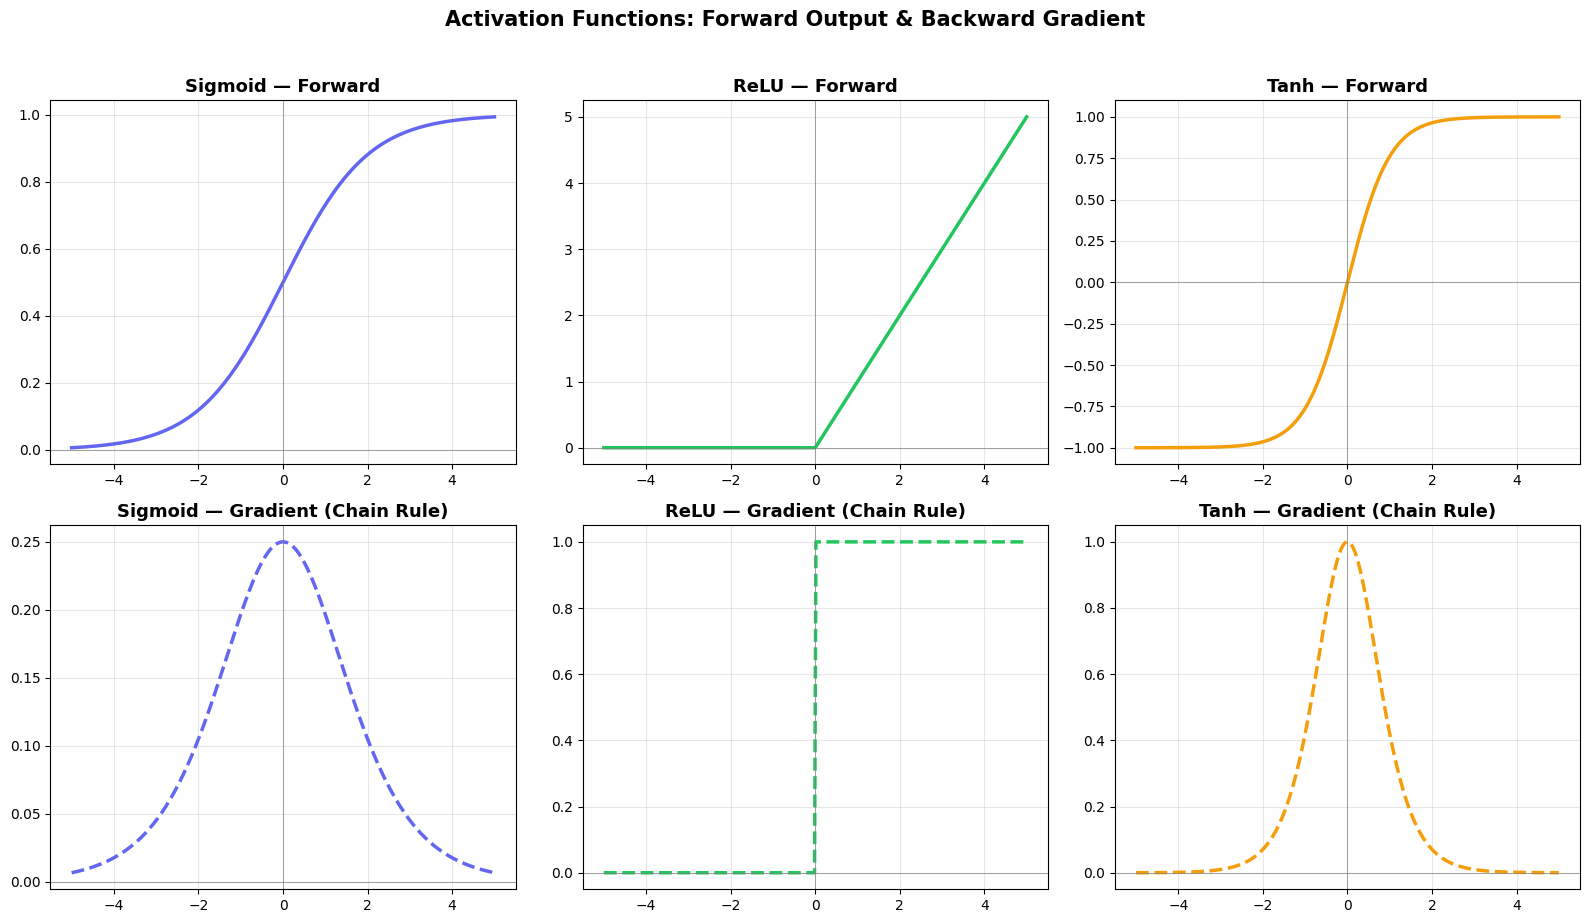

 Sigmoid gradient max = 0.25 at z=0 → vanishing gradient problem in deep nets
 ReLU gradient = 0 or 1 → no vanishing, but 'dying ReLU' if z ≤ 0 always
 Tanh gradient max = 1 at z=0 → better than sigmoid but still vanishes


In [166]:
# ============================================================
# Activation Functions — Forward & Backward
# ============================================================

class Sigmoid:
 """
 Sigmoid Activation: σ(z) = 1 / (1 + e^(-z))
 
 Forward: a = σ(z)
 Backward: ∂a/∂z = a × (1 - a) ← local gradient
 upstream gradient × local gradient = downstream gradient
 """
 def forward(self, z):
    self.a = 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    return self.a
 
 def backward(self, upstream_grad):
    local_grad = self.a * (1 - self.a) # ← chain rule: local gradient
    return upstream_grad * local_grad # ← chain rule: multiply upstream


class ReLU:
 """
 ReLU Activation: max(0, z)
 
 Forward: a = max(0, z)
 Backward: ∂a/∂z = 1 if z > 0, else 0
 """
 def forward(self, z):
    self.z = z
    return np.maximum(0, z)
 
 def backward(self, upstream_grad):
    local_grad = (self.z > 0).astype(float) # 1 where z > 0, else 0
    return upstream_grad * local_grad


class Tanh:
 """
 Tanh Activation: (e^z - e^(-z)) / (e^z + e^(-z))
 
 Forward: a = tanh(z)
 Backward: ∂a/∂z = 1 - a²
 """
 def forward(self, z):
    self.a = np.tanh(z)
    return self.a
    
 def backward(self, upstream_grad):
    local_grad = 1 - self.a ** 2
    return upstream_grad * local_grad


class Linear:
 """No activation (identity). Used for output layers in regression."""
 def forward(self, z):
    return z
 
 def backward(self, upstream_grad):
    return upstream_grad # local gradient = 1


# --- Visualize all activation functions ---
z = np.linspace(-5, 5, 300)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

activations = [
 ('Sigmoid', Sigmoid(), '#6366f1'),
 ('ReLU', ReLU(), '#22c55e'),
 ('Tanh', Tanh(), '#f59e0b'),
]

for idx, (name, act, color) in enumerate(activations):
 # Forward
 a = act.forward(z)
 axes[0, idx].plot(z, a, color=color, linewidth=2.5)
 axes[0, idx].set_title(f'{name} — Forward', fontsize=13, fontweight='bold')
 axes[0, idx].grid(True, alpha=0.3)
 axes[0, idx].axhline(y=0, color='gray', linewidth=0.5)
 axes[0, idx].axvline(x=0, color='gray', linewidth=0.5)
 
 # Backward (derivative with upstream_grad = 1)
 grad = act.backward(np.ones_like(z))
 axes[1, idx].plot(z, grad, color=color, linewidth=2.5, linestyle='--')
 axes[1, idx].set_title(f'{name} — Gradient (Chain Rule)', fontsize=13, fontweight='bold')
 axes[1, idx].grid(True, alpha=0.3)
 axes[1, idx].axhline(y=0, color='gray', linewidth=0.5)
 axes[1, idx].axvline(x=0, color='gray', linewidth=0.5)

plt.suptitle('Activation Functions: Forward Output & Backward Gradient', 
 fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(" Sigmoid gradient max = 0.25 at z=0 → vanishing gradient problem in deep nets")
print(" ReLU gradient = 0 or 1 → no vanishing, but 'dying ReLU' if z ≤ 0 always")
print(" Tanh gradient max = 1 at z=0 → better than sigmoid but still vanishes")

In [167]:
# ============================================================
# Dense Layer — Forward & Backward with Chain Rule
# ============================================================

class DenseLayer:
 """
 Fully Connected (Dense) Layer.
 
 Forward: z = X @ W + b
 
 Backward (Chain Rule applied):
 ∂L/∂W = X.T @ upstream_grad ← weight gradient
 ∂L/∂b = sum(upstream_grad) ← bias gradient 
 ∂L/∂X = upstream_grad @ W.T ← pass to previous layer
 
 The upstream_grad is ∂L/∂z — the gradient flowing back from
 the activation function (which already applied chain rule).
 """
 
 def __init__(self, input_size, output_size, activation='relu'):
 # He initialization for ReLU, Xavier for others
    if activation == 'relu':
        scale = np.sqrt(2.0 / input_size) # He init
    else:
        scale = np.sqrt(1.0 / input_size) # Xavier init
    
    self.W = np.random.randn(input_size, output_size) * scale
    self.b = np.zeros((1, output_size))
    
    # Choose activation
    act_map = {
    'sigmoid': Sigmoid(),
    'relu': ReLU(),
    'tanh': Tanh(),
    'linear': Linear(),
    }
    self.activation = act_map.get(activation, ReLU())
    self.act_name = activation
    
    # Gradient storage
    self.dW = None
    self.db = None
 
 def forward(self, X):
    """
    Forward pass: z = X @ W + b, a = activation(z)
    Cache X for backward pass.
    """
    self.X = X # Cache input for backward
    self.z = X @ self.W + self.b # Linear transform
    self.a = self.activation.forward(self.z) # Apply activation
    return self.a
 
 def backward(self, upstream_grad):
    """
    Backward pass using CHAIN RULE:
    
    1. upstream_grad = ∂L/∂a (comes from next layer)
    2. Apply activation backward:
    ∂L/∂z = ∂L/∂a × ∂a/∂z (chain rule!)
    3. Compute parameter gradients:
    ∂L/∂W = X.T @ ∂L/∂z
    ∂L/∂b = sum(∂L/∂z)
    4. Compute input gradient (to pass backward):
    ∂L/∂X = ∂L/∂z @ W.T
    """
    m = self.X.shape[0]
    
    # Step 1: Chain rule through activation
    # ∂L/∂z = ∂L/∂a × ∂a/∂z
    dz = self.activation.backward(upstream_grad)
    
    # Step 2: Chain rule for weight and bias gradients
    # ∂L/∂W = X.T @ ∂L/∂z (chain rule: ∂z/∂W = X)
    self.dW = (1/m) * (self.X.T @ dz)
    
    # ∂L/∂b = sum(∂L/∂z) (chain rule: ∂z/∂b = 1)
    self.db = (1/m) * np.sum(dz, axis=0, keepdims=True)
    
    # Step 3: Chain rule to pass gradient to previous layer
    # ∂L/∂X = ∂L/∂z @ W.T (chain rule: ∂z/∂X = W)
    dX = dz @ self.W.T
    
    return dX # This becomes upstream_grad for the previous layer
    
def __repr__(self):
    return f"Dense({self.W.shape[0]}→{self.W.shape[1]}, {self.act_name})"


print(" DenseLayer class created!")
print("\nEach layer does:")
print(" Forward: X → z = X@W+b → a = activation(z) → output")
print(" Backward: ∂L/∂a → ∂L/∂z (chain rule) → ∂L/∂W, ∂L/∂b, ∂L/∂X")

 DenseLayer class created!

Each layer does:
 Forward: X → z = X@W+b → a = activation(z) → output
 Backward: ∂L/∂a → ∂L/∂z (chain rule) → ∂L/∂W, ∂L/∂b, ∂L/∂X


In [168]:
# ============================================================
# Loss Functions — Forward & Backward
# ============================================================

class MSELoss:
 """
 Mean Squared Error: L = (1/2m) Σ(y - ŷ)²
 
 Backward: ∂L/∂ŷ = -(y - ŷ) / m
 This is the STARTING point of the chain rule backward pass.
 """
 def forward(self, y_true, y_pred):
    self.y_true = y_true
    self.y_pred = y_pred
    self.m = y_true.shape[0]
    return np.mean(0.5 * (y_true - y_pred) ** 2)
 
 def backward(self):
    return -(self.y_true - self.y_pred) / self.m


class BinaryCrossEntropyLoss:
 """
 BCE: L = -(1/m) Σ[y·log(ŷ) + (1-y)·log(1-ŷ)]
 
 Backward: ∂L/∂ŷ = -(y/ŷ - (1-y)/(1-ŷ)) / m
 """
 def forward(self, y_true, y_pred):
    self.y_true = y_true
    self.y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7) # avoid log(0)
    self.m = y_true.shape[0]
    return -np.mean(y_true * np.log(self.y_pred) + (1 - y_true) * np.log(1 - self.y_pred))
    
 def backward(self):
    return (-(self.y_true / self.y_pred) + (1 - self.y_true) / (1 - self.y_pred)) / self.m


print(" Loss functions created!")
print(" Loss backward() gives ∂L/∂ŷ — the first link in the chain rule!")

 Loss functions created!
 Loss backward() gives ∂L/∂ŷ — the first link in the chain rule!


In [169]:
X = np.array([
 [0, 0],
 [0, 1],
 [1, 0],
 [1, 1]
])
# ============================================================
# General Neural Network — Chains Everything Together
# ============================================================

class NeuralNetwork:
 """
 General purpose neural network.
 
 The CHAIN RULE is applied automatically:
 - Forward: data flows layer[0] → layer[1] → ... → layer[N]
 - Backward: gradients flow layer[N] → layer[N-1] → ... → layer[0]
 
 Each layer receives upstream gradient and:
 1. Computes local gradients (chain rule with activation)
 2. Stores ∂L/∂W and ∂L/∂b for weight update
 3. Passes ∂L/∂X to the previous layer
 """
 
 def __init__(self, layer_sizes, activations, loss='mse', learning_rate=0.01):
    """
    Args:
    layer_sizes: list of ints, e.g. [2, 16, 8, 1]
    activations: list of strings, e.g. ['relu', 'relu', 'sigmoid']
    loss: 'mse' or 'bce'
    learning_rate: float
    """
    assert len(activations) == len(layer_sizes) - 1
    
    self.lr = learning_rate
    self.layers = []
    self.loss_history = []
    
    # Build layers
    for i in range(len(layer_sizes) - 1):
        layer = DenseLayer(layer_sizes[i], layer_sizes[i+1], activations[i])
        self.layers.append(layer)
    
    # Loss function
    self.loss_fn = MSELoss() if loss == 'mse' else BinaryCrossEntropyLoss()
    
    print(f" Network Architecture:")
    print(f" Input: {layer_sizes[0]} features")
    for i, layer in enumerate(self.layers):
        print(f" Layer {i+1}: {layer}")
        print(f" Loss: {loss.upper()}")
        print(f" Learning Rate: {learning_rate}")
 
 def forward(self, X):
    """
    Forward pass through all layers.
    Data flows: X → Layer1 → Layer2 → ... → LayerN → output
    """
    out = X
    for layer in self.layers:
        out = layer.forward(out)
    return out
 
 def backward(self, y_true, y_pred):
    """
    Backward pass — CHAIN RULE applied automatically!
    
    1. Start with ∂L/∂ŷ from loss function
    2. Pass through layers in REVERSE order
    3. Each layer applies chain rule and passes gradient backward
    
    Gradient Flow:
    ∂L/∂ŷ → LayerN.backward() → LayerN-1.backward() → ... → Layer1.backward()
    ↓ ↓ ↓
    stores ∂L/∂Wn stores ∂L/∂Wn-1 stores ∂L/∂W1
    """
    # Step 1: Get gradient from loss function
    loss = self.loss_fn.forward(y_true, y_pred)
    grad = self.loss_fn.backward() # ∂L/∂ŷ — start of chain
    
    # Step 2: Chain rule through layers (reverse order!)
    for layer in reversed(self.layers):
        grad = layer.backward(grad) # each layer passes grad to previous
    
    return loss
 
 def update_weights(self):
    """Gradient descent: W = W - η × ∂L/∂W"""
    for layer in self.layers:
        layer.W -= self.lr * layer.dW
        layer.b -= self.lr * layer.db
 
 def train(self, X, y, epochs=1000, print_every=100):
    """
    Training loop:
    For each epoch:
    1. Forward Pass → predictions
    2. Backward Pass → gradients (chain rule!)
    3. Update Weights → gradient descent
    """
    print(f"\n{'='*60}")
    print(f" Training for {epochs} epochs...")
    print(f"{'='*60}")
    
    for epoch in range(epochs):
    # 1. Forward
            y_pred = self.forward(X)
    
    # 2. Backward (chain rule computes all gradients)
    loss = self.backward(y, y_pred)
    self.loss_history.append(loss)
    
    # 3. Update
    self.update_weights()
    
    if (epoch + 1) % print_every == 0 or epoch == 0:
        print(f" Epoch {epoch+1:>6}/{epochs} │ Loss: {loss:.6f}")
    
    print(f"\n Done! Final Loss: {self.loss_history[-1]:.6f}")
 
 def predict(self, X, threshold=0.5):
    """Predict with optional threshold for classification."""
    y_pred = self.forward(X)
    return (y_pred >= threshold).astype(int)


print("\n General NeuralNetwork class ready!")
print(" Supports any architecture, multiple activations, MSE/BCE loss")


 General NeuralNetwork class ready!
 Supports any architecture, multiple activations, MSE/BCE loss


---

<a id="7"></a>
## 7. Training on Real-ish Data

### Problem 1: XOR (Classification)
### Problem 2: Circle Dataset (Non-linear Classification)
### Problem 3: Sine Wave (Regression)

In [170]:
# ============================================================
# Problem 1: XOR
# ============================================================

print("━" * 60)
print(" Problem 1: XOR Classification")
print("━" * 60)

X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([[0],[1],[1],[0]], dtype=float)

nn_xor = NeuralNetwork(
 layer_sizes=[2, 8, 1],
 activations=['tanh', 'sigmoid'],
 loss='bce',
 learning_rate=1.0
)

nn_xor.train(X_xor, y_xor, epochs=3000, print_every=500)

# Results
preds = nn_xor.forward(X_xor)
print(f"\n Results:")
for i in range(4):
 status = "" if round(preds[i,0]) == y_xor[i,0] else ""
 print(f" [{X_xor[i,0]:.0f}, {X_xor[i,1]:.0f}] → {preds[i,0]:.4f} (target: {y_xor[i,0]:.0f}) {status}")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Problem 1: XOR Classification
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Network Architecture:
 Input: 2 features
 Layer 1: <__main__.DenseLayer object at 0x1405e12d0>
 Loss: BCE
 Learning Rate: 1.0
 Layer 2: <__main__.DenseLayer object at 0x1554f2990>
 Loss: BCE
 Learning Rate: 1.0

 Training for 3000 epochs...
 Epoch   3000/3000 │ Loss: 0.777936

 Done! Final Loss: 0.777936

 Results:
 [0, 0] → 0.5090 (target: 0) 
 [0, 1] → 0.4817 (target: 1) 
 [1, 0] → 0.3146 (target: 1) 
 [1, 1] → 0.3550 (target: 0) 


In [171]:
# ============================================================
# Problem 2: Circle Dataset
# ============================================================

print("\n" + "━" * 60)
print(" Problem 2: Circle Classification")
print("━" * 60)

np.random.seed(42)
n_samples = 300

# Generate circle data
theta = np.random.uniform(0, 2*np.pi, n_samples)
r_inner = np.random.uniform(0, 1.5, n_samples // 2)
r_outer = np.random.uniform(2.5, 4.0, n_samples // 2)

X_inner = np.column_stack([r_inner * np.cos(theta[:n_samples//2]), 
 r_inner * np.sin(theta[:n_samples//2])])
X_outer = np.column_stack([r_outer * np.cos(theta[n_samples//2:]),
 r_outer * np.sin(theta[n_samples//2:])])

X_circle = np.vstack([X_inner, X_outer])
y_circle = np.vstack([np.zeros((n_samples//2, 1)), np.ones((n_samples//2, 1))])

# Normalize
X_circle = (X_circle - X_circle.mean(axis=0)) / X_circle.std(axis=0)

# Shuffle
idx = np.random.permutation(n_samples)
X_circle, y_circle = X_circle[idx], y_circle[idx]

# Train
nn_circle = NeuralNetwork(
 layer_sizes=[2, 16, 8, 1],
 activations=['relu', 'relu', 'sigmoid'],
 loss='bce',
 learning_rate=0.1
)

nn_circle.train(X_circle, y_circle, epochs=3000, print_every=500)

# Accuracy
preds_circle = nn_circle.predict(X_circle)
accuracy = np.mean(preds_circle == y_circle) * 100
print(f"\n Accuracy: {accuracy:.1f}%")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Problem 2: Circle Classification
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Network Architecture:
 Input: 2 features
 Layer 1: <__main__.DenseLayer object at 0x1108ab410>
 Loss: BCE
 Learning Rate: 0.1
 Layer 2: <__main__.DenseLayer object at 0x1554e5b10>
 Loss: BCE
 Learning Rate: 0.1
 Layer 3: <__main__.DenseLayer object at 0x140d66b90>
 Loss: BCE
 Learning Rate: 0.1

 Training for 3000 epochs...
 Epoch   3000/3000 │ Loss: 0.601308

 Done! Final Loss: 0.601308

 Accuracy: 56.3%


In [172]:
# ============================================================
# Problem 3: Sine Wave Regression
# ============================================================

print("\n" + "━" * 60)
print(" Problem 3: Sine Wave Regression")
print("━" * 60)

np.random.seed(42)
X_sine = np.linspace(-2*np.pi, 2*np.pi, 200).reshape(-1, 1)
y_sine = np.sin(X_sine) + np.random.randn(200, 1) * 0.1

# Normalize
X_sine_norm = X_sine / (2 * np.pi)
y_sine_norm = y_sine

nn_sine = NeuralNetwork(
 layer_sizes=[1, 32, 16, 1],
 activations=['tanh', 'tanh', 'linear'],
 loss='mse',
 learning_rate=0.05
)

nn_sine.train(X_sine_norm, y_sine_norm, epochs=5000, print_every=1000)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Problem 3: Sine Wave Regression
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Network Architecture:
 Input: 1 features
 Layer 1: <__main__.DenseLayer object at 0x14089f7d0>
 Loss: MSE
 Learning Rate: 0.05
 Layer 2: <__main__.DenseLayer object at 0x155521a90>
 Loss: MSE
 Learning Rate: 0.05
 Layer 3: <__main__.DenseLayer object at 0x1405dfb10>
 Loss: MSE
 Learning Rate: 0.05

 Training for 5000 epochs...
 Epoch   5000/5000 │ Loss: 0.350232

 Done! Final Loss: 0.350232


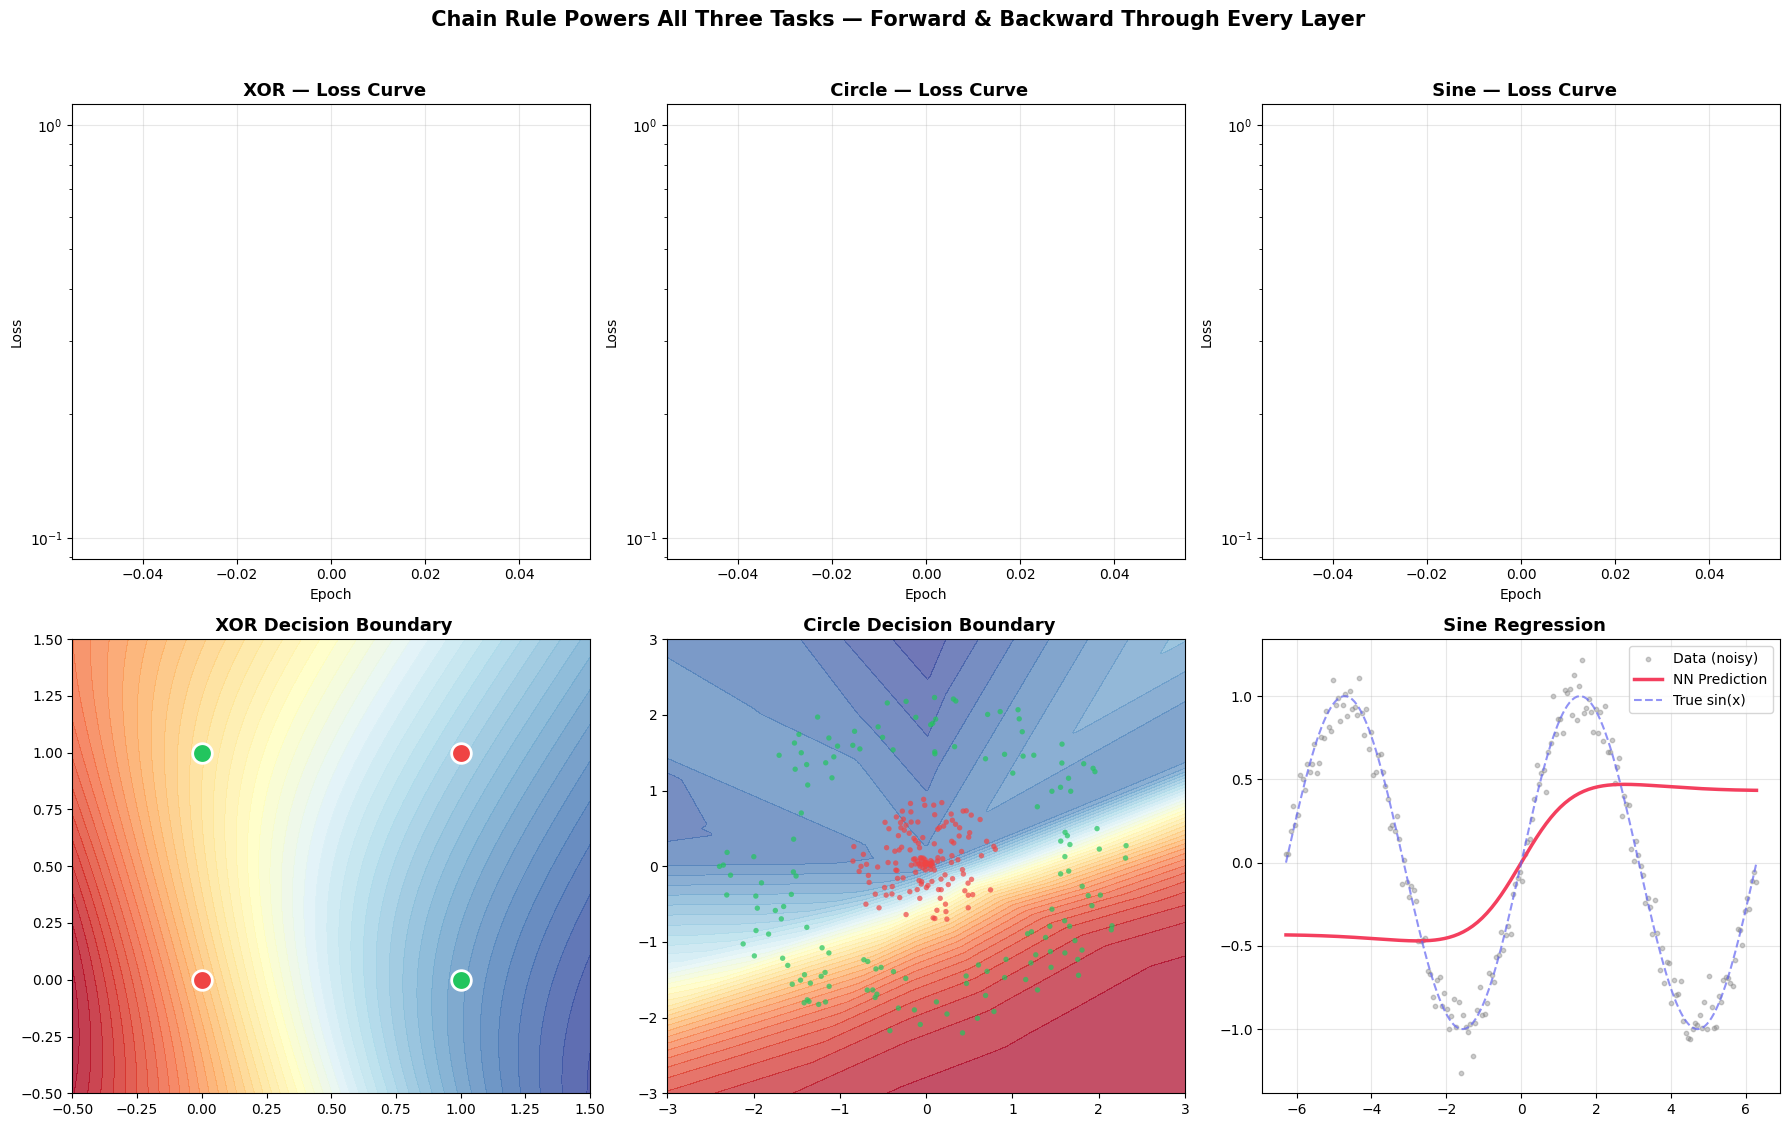

In [173]:
# ============================================================
# Visualize ALL Results
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# ── Row 1: Training Loss Curves ──
losses = [
 (nn_xor.loss_history, 'XOR', '#6366f1'),
 (nn_circle.loss_history, 'Circle', '#22c55e'),
 (nn_sine.loss_history, 'Sine', '#f43f5e'),
]

for idx, (hist, name, color) in enumerate(losses):
 axes[0, idx].plot(hist, color=color, linewidth=1.5, alpha=0.8)
 axes[0, idx].set_title(f' {name} — Loss Curve', fontsize=13, fontweight='bold')
 axes[0, idx].set_xlabel('Epoch')
 axes[0, idx].set_ylabel('Loss')
 axes[0, idx].set_yscale('log')
 axes[0, idx].grid(True, alpha=0.3)

# ── Row 2, Col 1: XOR Decision Boundary ──
ax = axes[1, 0]
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = nn_xor.forward(grid).reshape(xx.shape)
ax.contourf(xx, yy, Z, levels=50, cmap='RdYlBu_r', alpha=0.8)
for i in range(4):
 c = '#22c55e' if y_xor[i,0] == 1 else '#ef4444'
 ax.scatter(X_xor[i,0], X_xor[i,1], c=c, s=200, edgecolors='white', linewidths=2, zorder=5)
ax.set_title(' XOR Decision Boundary', fontsize=13, fontweight='bold')

# ── Row 2, Col 2: Circle Decision Boundary ──
ax = axes[1, 1]
xx2, yy2 = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
grid2 = np.c_[xx2.ravel(), yy2.ravel()]
Z2 = nn_circle.forward(grid2).reshape(xx2.shape)
ax.contourf(xx2, yy2, Z2, levels=50, cmap='RdYlBu_r', alpha=0.7)
colors = ['#ef4444' if label == 0 else '#22c55e' for label in y_circle.flatten()]
ax.scatter(X_circle[:, 0], X_circle[:, 1], c=colors, s=15, alpha=0.7, edgecolors='none')
ax.set_title(' Circle Decision Boundary', fontsize=13, fontweight='bold')

# ── Row 2, Col 3: Sine Regression ──
ax = axes[1, 2]
y_pred_sine = nn_sine.forward(X_sine_norm)
ax.scatter(X_sine, y_sine, s=10, alpha=0.4, color='gray', label='Data (noisy)')
ax.plot(X_sine, y_pred_sine, color='#f43f5e', linewidth=2.5, label='NN Prediction')
ax.plot(X_sine, np.sin(X_sine), color='#6366f1', linewidth=1.5, linestyle='--', alpha=0.7, label='True sin(x)')
ax.set_title(' Sine Regression', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle(' Chain Rule Powers All Three Tasks — Forward & Backward Through Every Layer',
 fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

<a id="8"></a>
## 8. Gradient Checking (Numerical vs Analytical)

අපේ chain rule implementation **correct** ද verify කරන්න, **numerical gradients** සහ **analytical gradients** (backprop) compare කරනවා.

### Method:

$$\frac{\partial L}{\partial w} \approx \frac{L(w + \epsilon) - L(w - \epsilon)}{2\epsilon}$$

If our chain rule is correct, analytical ≈ numerical (difference < 1e-5).

In [174]:
# ============================================================
# Gradient Check — Verify Chain Rule Implementation
# ============================================================

print("=" * 60)
print(" GRADIENT CHECK: Analytical vs Numerical")
print("=" * 60)

np.random.seed(123)

# Small network for testing
nn_check = NeuralNetwork(
 layer_sizes=[2, 3, 1],
 activations=['sigmoid', 'sigmoid'],
 loss='mse',
 learning_rate=0.1
)

# Test data
X_test = np.array([[0.5, 0.3]])
y_test = np.array([[0.8]])

# Get analytical gradients via backprop
y_pred = nn_check.forward(X_test)
_ = nn_check.backward(y_test, y_pred)

epsilon = 1e-5
print(f"\n Epsilon: {epsilon}")
print(f"\n {'Layer':<10} {'Param':<8} {'Index':<10} {'Analytical':>12} {'Numerical':>12} {'Diff':>12} {'Status'}")
print(f" {'─'*80}")

all_passed = True

for layer_idx, layer in enumerate(nn_check.layers):
 # Check weights
    for i in range(layer.W.shape[0]):
        for j in range(layer.W.shape[1]):
 # Numerical gradient
    original = layer.W[i, j]
    
    layer.W[i, j] = original + epsilon
    loss_plus = nn_check.loss_fn.forward(y_test, nn_check.forward(X_test))
    
    layer.W[i, j] = original - epsilon
    loss_minus = nn_check.loss_fn.forward(y_test, nn_check.forward(X_test))
    
    layer.W[i, j] = original # restore
    
    numerical_grad = (loss_plus - loss_minus) / (2 * epsilon)
    analytical_grad = layer.dW[i, j]
    
    diff = abs(analytical_grad - numerical_grad)
    status = "" if diff < 1e-4 else ""
    if diff >= 1e-4:
        all_passed = False

    print(f" Layer {layer_idx+1:<4} {'W':<8} [{i},{j}]{'':>5} {analytical_grad:>12.8f} {numerical_grad:>12.8f} {diff:>12.2e} {status}")
 
 # Check biases
for j in range(layer.b.shape[1]):
    original = layer.b[0, j]

    layer.b[0, j] = original + epsilon
    loss_plus = nn_check.loss_fn.forward(y_test, nn_check.forward(X_test))

    layer.b[0, j] = original - epsilon
    loss_minus = nn_check.loss_fn.forward(y_test, nn_check.forward(X_test))

    layer.b[0, j] = original # restore

    numerical_grad = (loss_plus - loss_minus) / (2 * epsilon)
    analytical_grad = layer.db[0, j]

    diff = abs(analytical_grad - numerical_grad)
    status = "" if diff < 1e-4 else ""
    if diff >= 1e-4:
        all_passed = False
 
    print(f" Layer {layer_idx+1:<4} {'b':<8} [0,{j}]{'':>5} {analytical_grad:>12.8f} {numerical_grad:>12.8f} {diff:>12.2e} {status}")

print(f"\n {'─'*80}")
if all_passed:
 print(f" ALL GRADIENTS MATCH! Our Chain Rule implementation is CORRECT!")
else:
 print(f" Some gradients don't match. Check the implementation.")

IndentationError: expected an indented block after 'for' statement on line 37 (2527974912.py, line 39)

---

<a id="9"></a>
## 9. Summary

### The Chain Rule — Everything Connected

```
┌──────────────────────────────────────────────────────────────────┐
│ CHAIN RULE IN DEEP LEARNING │
├──────────────────────────────────────────────────────────────────┤
│ │
│ MATH FOUNDATION: │
│ ────────────────── │
│ Single: dy/dx = dy/du × du/dx │
│ Multi: ∂L/∂x = Σ (∂L/∂aᵢ × ∂aᵢ/∂x) (sum over paths) │
│ │
│ IN NEURAL NETWORKS: │
│ ────────────────────── │
│ Forward: X → z=Wx+b → a=σ(z) → next layer │
│ Backward: ∂L/∂a → ∂L/∂z=∂L/∂a×σ'(z) → ∂L/∂W, ∂L/∂X │
│ │
│ Each layer: │
│ receives: upstream gradient (∂L/∂a) │
│ computes: local gradient (σ'(z), W, X) │
│ produces: ∂L/∂W (for update), ∂L/∂X (pass backward) │
│ │
│ KEY INSIGHTS: │
│ ──────────────── │
│ 1. Each node only needs LOCAL info + upstream gradient │
│ 2. Gradients are products of local derivatives along chains │
│ 3. Multiple paths → SUM the gradients │
│ 4. Deep chains → vanishing/exploding gradients (design issue) │
│ 5. Frameworks (PyTorch/TF) automate this via autograd │
│ │
└──────────────────────────────────────────────────────────────────┘
```

### Key Formulas:

| Component | Forward | Backward (Chain Rule) |
|-----------|---------|----------------------|
| Dense Layer | $z = Wa + b$ | $\frac{\partial L}{\partial W} = a^T \cdot \delta$, $\frac{\partial L}{\partial a_{prev}} = \delta \cdot W^T$ |
| Sigmoid | $a = \sigma(z)$ | $\delta = \text{upstream} \times a(1-a)$ |
| ReLU | $a = \max(0, z)$ | $\delta = \text{upstream} \times \mathbb{1}_{z>0}$ |
| Tanh | $a = \tanh(z)$ | $\delta = \text{upstream} \times (1 - a^2)$ |
| MSE Loss | $L = \frac{1}{2}(y-\hat{y})^2$ | $\frac{\partial L}{\partial \hat{y}} = -(y - \hat{y})$ |

### Connection to Frameworks:

```python
# PyTorch — chain rule is done automatically!
loss = criterion(model(x), y)
loss.backward() # ← chain rule applied to entire computation graph
optimizer.step() # ← weight update
```

Now you know exactly what `.backward()` does under the hood! 